# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve, roc_auc_score
)

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\ganna\Downloads\GUC_2350_68_67032_2026-04-08T17_06_08\Lab 5\heart.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df['target'].value_counts())

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Target distribution:
target
1    165
0    138
Name: count, dtype: int64


# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [ ]:
X = df.drop('target', axis=1)   
y = df['target']                 

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=101
)

print("Training samples :", X_train.shape[0])
print("Test samples     :", X_test.shape[0])

Training samples : 272
Test samples     : 31


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [5]:
scaler = StandardScaler()

# Fit on training data only, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # transform only — no fit!

print("Scaling complete.")
print("X_train_scaled mean (should be ~0):", X_train_scaled.mean(axis=0).round(4))

Scaling complete.
X_train_scaled mean (should be ~0): [-0. -0. -0.  0.  0.  0. -0.  0.  0. -0. -0.  0. -0.]


## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [6]:
log_model = LogisticRegression(random_state=101, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


### Coeffecients

**TASK: Report back the model's coefficients.**

Logistic Regression Coefficients:


,Coefficient
cp,0.893801
thalach,0.433618
slope,0.381934
restecg,0.120059
fbs,0.046268
age,-0.072005
chol,-0.212529
trestbps,-0.262634
exang,-0.428155
oldpeak,-0.526155


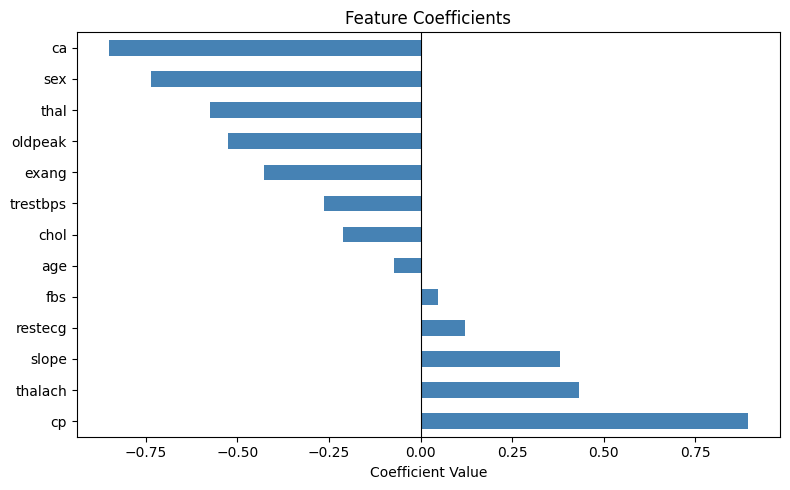

In [7]:
coeff_df = pd.DataFrame(
    log_model.coef_[0],
    index=X.columns,
    columns=['Coefficient']
).sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
display(coeff_df)

# Visual
plt.figure(figsize=(8, 5))
coeff_df['Coefficient'].plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [8]:
y_pred       = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)

Confusion Matrix Array:
[[12  3]
 [ 2 14]]


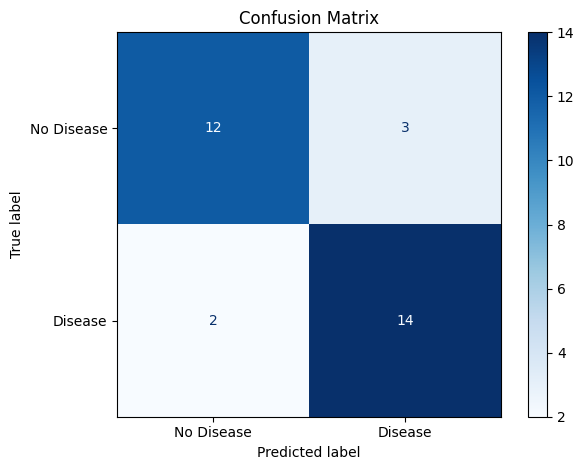

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.80      0.83        15
     Disease       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TASK: Create the ROC Curve.**

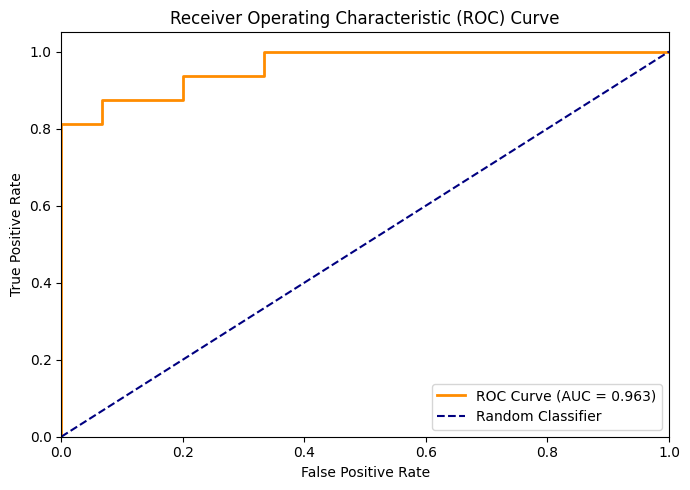

AUC Score: 0.9625


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

c:\Users\ganna\anaaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


 NEW PATIENT PREDICTION REPORT
Prediction         : HEART DISEASE
Probability (No Disease) : 2.04%
Probability (Disease)    : 97.96%


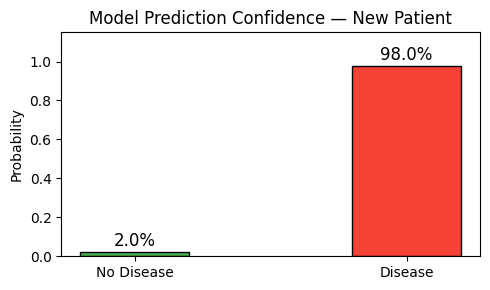

In [14]:
# New patient features (in the same column order as X)
patient = np.array([[48.0, 0.0, 2.0, 130.0, 275.0,
                     0.0, 1.0, 139.0, 0.0, 0.2,
                     2.0, 0.0, 2.0]])

# Scale using the SAME scaler fitted on training data
patient_scaled = scaler.transform(patient)

# Prediction
prediction     = log_model.predict(patient_scaled)[0]
probabilities  = log_model.predict_proba(patient_scaled)[0]  # [P(no disease), P(disease)]


print(" NEW PATIENT PREDICTION REPORT")

print(f"Prediction         : {'HEART DISEASE' if prediction == 1 else 'NO HEART DISEASE'}")
print(f"Probability (No Disease) : {probabilities[0]*100:.2f}%")
print(f"Probability (Disease)    : {probabilities[1]*100:.2f}%")


# Confidence bar
labels = ['No Disease', 'Disease']
colors = ['#4CAF50','#F44336']
plt.figure(figsize=(5, 3))
bars = plt.bar(labels, probabilities, color=colors, edgecolor='black', width=0.4)
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=12)
plt.ylim(0, 1.15)
plt.title('Model Prediction Confidence — New Patient')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()